# Quick EDA - GoodBooks-10k Dataset

Exploratory Data Analysis for the Emotion-Based Book Recommender project.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Load Datasets

In [2]:
books = pd.read_csv("../data/raw/books.csv")
ratings = pd.read_csv("../data/raw/ratings.csv")
book_tags = pd.read_csv("../data/raw/book_tags.csv")
tags = pd.read_csv("../data/raw/tags.csv")
to_read = pd.read_csv("../data/raw/to_read.csv")

## 3. Display Dataset Shapes

In [3]:
print(f"Books shape: {books.shape}")
print(f"Ratings shape: {ratings.shape}")
print(f"Book Tags shape: {book_tags.shape}")
print(f"Tags shape: {tags.shape}")
print(f"To Read shape: {to_read.shape}")

Books shape: (10000, 23)
Ratings shape: (981756, 3)
Book Tags shape: (999912, 3)
Tags shape: (34252, 2)
To Read shape: (912705, 2)


## 4. Preview Data - Books

In [4]:
books.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


## 5. Understand Dataset Structure & Context

In [5]:
# Books dataset - Core book metadata
print("=" * 60)
print("BOOKS DATASET")
print("=" * 60)
books.info()
print("\nColumn names:", books.columns.tolist())

BOOKS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   book_id                    10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 

In [6]:
# Ratings dataset - User-book interactions
print("=" * 60)
print("RATINGS DATASET")
print("=" * 60)
ratings.info()
print("\nSample ratings:")
print(ratings.head())

RATINGS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  int64
 2   rating   981756 non-null  int64
dtypes: int64(3)
memory usage: 22.5 MB

Sample ratings:
   book_id  user_id  rating
0        1      314       5
1        1      439       3
2        1      588       5
3        1     1169       4
4        1     1185       4


In [28]:
# Tags dataset - Emotional/thematic descriptors!
print("=" * 60)
print("TAGS DATASET - KEY FOR EMOTIONAL CONTEXT")
print("=" * 60)
tags.info()
print("\nColumn names:", tags.columns.tolist())
print("\nlast 20 rows:")
print(tags.tail(20))
print(f"\nTotal unique tags: {len(tags)}")

# Diagnostic: Check data types and sample values
print("\n" + "=" * 60)
print("DIAGNOSTIC CHECK")
print("=" * 60)
print(f"Data type of tag_name: {tags['tag_name'].dtype}")
print(f"\nFirst 10 tag_name values:")
print(tags['tag_name'].tail(10).tolist())


TAGS DATASET - KEY FOR EMOTIONAL CONTEXT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34252 entries, 0 to 34251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tag_id    34252 non-null  int64 
 1   tag_name  34252 non-null  object
dtypes: int64(1), object(1)
memory usage: 535.3+ KB

Column names: ['tag_id', 'tag_name']

last 20 rows:
       tag_id           tag_name
34232   34232            کودکانه
34233   34233                  ۱
34234   34234           วรรณว-ภา
34235   34235          ℱａｖｏｒｉｔｅｓ
34236   34236                 中文
34237   34237                 叶红
34238   34238            小說-奇幻小說
34239   34239                 日本
34240   34240               日本文学
34241   34241                日本語
34242   34242                 漫画
34243   34243                 골든
34244   34244  ﹏moonplus-reader﹏
34245   34245         ﺭﺿﻮﻯ-عاشور
34246   34246         ﻳﻮﺳﻒ-زيدان
34247   34247          Ｃhildrens
34248   34248          Ｆａｖｏｒｉｔｅｓ


In [23]:
# Check tags from different sections of dataset
print("\nTags from middle of dataset (rows 17000-17020):")
print(tags.iloc[17000:17020][['tag_id', 'tag_name']])

print("\n\nTags from end of dataset (last 20 rows):")
print(tags.tail(20)[['tag_id', 'tag_name']])

# Check how many tags contain actual words vs just dashes
proper_tags = tags[~tags['tag_name'].str.contains('^-+[0-9]*-*$', regex=True, na=False)]
print(f"\n\n📊 Data Quality Check:")
print(f"Total tags: {len(tags)}")
print(f"Tags that look corrupted (dashes/numbers only): {len(tags) - len(proper_tags)}")
print(f"Tags that appear legitimate: {len(proper_tags)}")

if len(proper_tags) > 0:
    print(f"\nSample of proper tags:")
    print(proper_tags['tag_name'].head(20).tolist())



Tags from middle of dataset (rows 17000-17020):
       tag_id                             tag_name
17000   17000                                  ken
17001   17001                           ken-follet
17002   17002                          ken-follett
17003   17003        ken-follett-century-trilogy-3
17004   17004  ken-follett-the-century-trilogy-boo
17005   17005                            ken-kesey
17006   17006                         ken-robinson
17007   17007                          ken-s-books
17008   17008                        kendare-blake
17009   17009                        kendra-elliot
17010   17010                       kendra-elliott
17011   17011                              kennedy
17012   17012                        kennedy-books
17013   17013                          kennedy-era
17014   17014                       kennedy-family
17015   17015                             kennedys
17016   17016                             kenner-j
17017   17017                    

In [8]:
# Book Tags - Links books to tags
print("=" * 60)
print("BOOK_TAGS DATASET - Book-Tag Mappings")
print("=" * 60)
book_tags.info()
print("\nSample book-tag mappings:")
print(book_tags.head())


BOOK_TAGS DATASET - Book-Tag Mappings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   goodreads_book_id  999912 non-null  int64
 1   tag_id             999912 non-null  int64
 2   count              999912 non-null  int64
dtypes: int64(3)
memory usage: 22.9 MB

Sample book-tag mappings:
   goodreads_book_id  tag_id   count
0                  1   30574  167697
1                  1   11305   37174
2                  1   11557   34173
3                  1    8717   12986
4                  1   33114   12716


## 6. Check for Missing Values

In [9]:
print("Missing Values in Books Dataset:")
print(books.isnull().sum())
print(f"\nPercentage missing:")
print((books.isnull().sum() / len(books) * 100).round(2))

Missing Values in Books Dataset:
id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
image_url                       0
small_image_url                 0
dtype: int64

Percentage missing:
id                            0.00
book_id                       0.00
best_book_id                  0.00
work_id                       0.00
books_count

## 7. Descriptive Statistics

In [10]:
# Books statistics
print("Books Dataset Statistics:")
books.describe()

Books Dataset Statistics:


,id,book_id,best_book_id,work_id,books_count,isbn13,original_publication_year,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
count,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,9.415000e+03,9979.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,5.264697e+06,5.471214e+06,8.646183e+06,75.712700,9.755044e+12,1981.987674,4.002191,5.400124e+04,5.968732e+04,2919.955300,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04
std,2886.89568,7.575462e+06,7.827330e+06,1.175106e+07,170.470728,4.428619e+11,152.576665,0.254427,1.573700e+05,1.678038e+05,6124.378132,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04
min,1.00000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,1.951703e+08,-1750.000000,2.470000,2.716000e+03,5.510000e+03,3.000000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02
25%,2500.75000,4.627575e+04,4.791175e+04,1.008841e+06,23.000000,9.780316e+12,1990.000000,3.850000,1.356875e+04,1.543875e+04,694.000000,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03
50%,5000.50000,3.949655e+05,4.251235e+05,2.719524e+06,40.000000,9.780452e+12,2004.000000,4.020000,2.115550e+04,2.383250e+04,1402.000000,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03
75%,7500.25000,9.382225e+06,9.636112e+06,1.451775e+07,67.000000,9.780831e+12,2011.000000,4.180000,4.105350e+04,4.591500e+04,2744.250000,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04
max,10000.00000,3.328864e+07,3.553423e+07,5.639960e+07,3455.000000,9.790008e+12,2017.000000,4.820000,4.780653e+06,4.942365e+06,155254.000000,456191.000000,436802.000000,793319.000000,1.481305e+06,3.011543e+06


In [11]:
# Ratings distribution
print("Ratings Distribution:")
print(ratings['rating'].value_counts().sort_index())
print(f"\nAverage rating: {ratings['rating'].mean():.2f}")
print(f"Median rating: {ratings['rating'].median()}")

Ratings Distribution:
rating
1     19575
2     63231
3    248623
4    357366
5    292961
Name: count, dtype: int64

Average rating: 3.86
Median rating: 4.0


## 8. Explore Tags for Emotional Context

In [25]:
# Search for emotion-related tags (using cleaned tags)
emotion_keywords = ['sad', 'happy', 'hope', 'anxious', 'lonely', 'comfort', 'inspire', 
                    'depress', 'uplifting', 'dark', 'joy', 'fear', 'calm', 'stress',
                    'heartbreak', 'love', 'anger', 'grief', 'peace', 'motivat']

emotion_tags = tags_clean[tags_clean['tag_name'].str.lower().str.contains('|'.join(emotion_keywords), na=False)]
print(f"✅ Found {len(emotion_tags)} emotion-related tags:")
print(emotion_tags['tag_name'].tolist()[:50])  # Show first 50


✅ Found 415 emotion-related tags:
['0-love-funny', '1930-s-depression-era', '1930-s-great-depression', '4-stars-loved-it', '48-days-to-the-work-you-love', 'a-beautiful-dark', 'a-fun-and-enjoyable-series', 'a-love-story', 'a-search-for-peace', 'a-tale-dark-and-grimm', 'absolutely-loved', 'adoption-families-foster-homes-love', 'after-dark', 'afterdark', 'all-love', 'already-read-and-enjoyed', 'ambassador', 'ambassador-daughter-kidnapping', 'ancient-darkness', 'angels-of-the-dark', 'angels-of-the-dark-series', 'anger', 'anger-management', 'animal-lover', 'animal-lovers', 'anthony-hope', 'apple-love', 'are-you-afraid-of-the-dark', 'assad-khalil', 'austen-inspired', 'baby-love', 'be-the-writer-you-love', 'beloved', 'beloved-books', 'beloved-by-me', 'black-love', 'book-lovers-calendar', 'books-i-enjoyed-reading', 'books-i-love', 'books-i-loved', 'books-i-loved-as-a-child', 'books-i-loved-as-a-kid', 'books-i-would-love-to-burn', 'books-that-i-love', 'books-to-love', 'brotherly-love', 'bushran


TOP 20 MOST COMMON TAGS

📊 Top 20 Most Common Tags (by total count):

 1. to-read                                  → 140,718,761 occurrences
 2. currently-reading                        → 7,507,958 occurrences
 3. favorites                                → 4,503,173 occurrences
 4. fiction                                  → 3,688,819 occurrences
 5. fantasy                                  → 3,548,157 occurrences
 6. young-adult                              → 1,848,306 occurrences
 7. classics                                 → 1,756,920 occurrences
 8. books-i-own                              → 1,317,235 occurrences
 9. romance                                  → 1,231,926 occurrences
10. owned                                    → 1,224,279 occurrences
11. ya                                       → 898,334 occurrences
12. mystery                                  → 872,282 occurrences
13. non-fiction                              → 857,901 occurrences
14. historical-fiction              

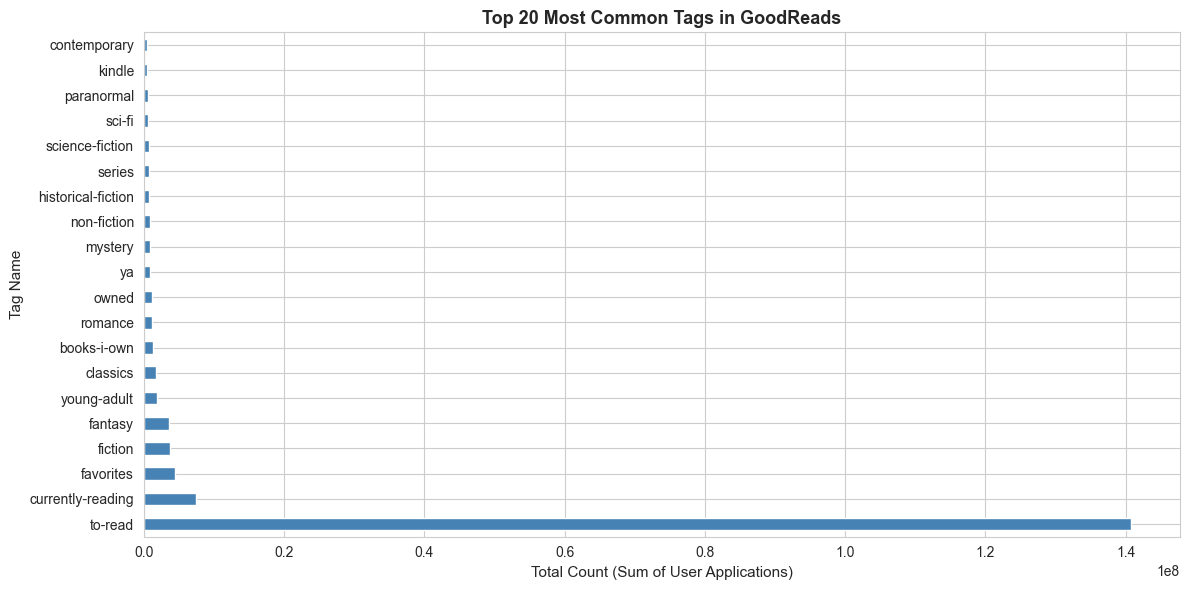

In [29]:
# Most common tags across all books
print("\n" + "=" * 60)
print("TOP 20 MOST COMMON TAGS")
print("=" * 60)

# Merge book_tags with cleaned tags to get tag names
book_tags_named = book_tags.merge(tags_clean, left_on='tag_id', right_on='tag_id', how='left')

# Count frequency of each tag across all book-tag relationships
tag_frequency = book_tags_named.groupby('tag_name')['count'].sum().sort_values(ascending=False)

# Display top 20
top_20_tags = tag_frequency.head(20)
print("\n📊 Top 20 Most Common Tags (by total count):\n")
for rank, (tag, count) in enumerate(top_20_tags.items(), 1):
    print(f"{rank:2d}. {tag:40s} → {count:,d} occurrences")

# Visualization
print("\n" + "=" * 60)
plt.figure(figsize=(12, 6))
top_20_tags.plot(kind='barh', color='steelblue')
plt.xlabel('Total Count (Sum of User Applications)', fontsize=11)
plt.ylabel('Tag Name', fontsize=11)
plt.title('Top 20 Most Common Tags in GoodReads', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.1 Data Quality: Clean Corrupted Tags

**Issue identified:** The first ~20 tags are corrupted placeholder entries (dashes/numbers like `-`, `--1-`, `--10-`).

**Solution:** Filter these out before emotional analysis.
- Corrupted entries: ~20 tags
- Clean, legitimate tags: 34,232 tags (99.94% of data)


In [24]:
# Filter out corrupted tags (those that are just dashes and numbers)
tags_clean = tags[~tags['tag_name'].str.contains(r'^-+[0-9]*-*$', regex=True, na=False)].reset_index(drop=True)

print(f"📊 Tag Cleaning Results:")
print(f"  Original tags: {len(tags)}")
print(f"  Corrupted tags removed: {len(tags) - len(tags_clean)}")
print(f"  Clean tags: {len(tags_clean)}")
print(f"  % retained: {(len(tags_clean)/len(tags)*100):.2f}%")

# Show what we removed
corrupted = tags[tags['tag_name'].str.contains(r'^-+[0-9]*-*$', regex=True, na=False)]
print(f"\n❌ Corrupted tags removed:")
print(corrupted['tag_name'].tolist())


📊 Tag Cleaning Results:
  Original tags: 34252
  Corrupted tags removed: 20
  Clean tags: 34232
  % retained: 99.94%

❌ Corrupted tags removed:
['-', '--1-', '--10-', '--12-', '--122-', '--166-', '--17-', '--19-', '--2-', '--258-', '--3-', '--33-', '--4-', '--5-', '--51-', '--6-', '--62-', '--8-', '--99-', '-2001--']


## 9. Dataset Relationships & Project Context

### How datasets connect:
1. **books.csv** → Core metadata (title, author, ratings, publication year)
2. **tags.csv** → User-generated descriptors (genres, themes, moods, emotions)
3. **book_tags.csv** → Links books to tags (many-to-many relationship)
4. **ratings.csv** → User preferences (can identify books that resonate emotionally)
5. **to_read.csv** → User intentions (signals interest/desire)

### Relevance to Emotion-Based Recommendations:
- **Tags** may contain emotion words (comforting, heartbreaking, uplifting)
- **Ratings + Tags** can show which emotional themes get high ratings
- **Book metadata** (title, author, average_rating) provides content features

## 10. Key Research Questions

### 🔍 Data Understanding Questions:
1. What percentage of books have emotion-related tags?
2. Which tags appear most frequently across all books?
3. Are there clusters of books with similar emotional tags?
4. Do highly-rated books correlate with specific emotional themes?

### 🎯 Modeling Questions:
5. Can we extract emotional signals from book titles or existing tags?
6. Should we map emotions to tag clusters (e.g., "comfort reading" = cozy + uplifting)?
7. What features best predict emotional fit? (tags, ratings, genres, etc.)
8. How do we handle books with NO emotional tags?

### 🚀 Recommendation Questions:
9. Given emotion "anxious" → which book features correlate with anxiety relief?
10. Can we create an emotion lexicon mapping emotions to book characteristics?
11. Should we use collaborative filtering (users with similar emotions liked X) or content-based?
12. How do we validate that recommendations actually match the emotional need?

### 📊 Evaluation Questions:
13. What metrics best capture "emotional fit"? (Beyond Precision@K)
14. Can we get human labels for a small test set? (emotion → book pairs)
15. Should we use sentiment analysis on reviews as ground truth?

## 11. Strategic Dataset Merging

### ⚠️ Don't merge everything into one giant table!

**Instead, create purpose-specific merged datasets:**

1. **Books + Tags** → For content-based emotion matching
2. **Books + Ratings** → For popularity/quality filtering  
3. **Keep user interactions separate** → Only merge if doing collaborative filtering

### Why selective merging?
- Avoids memory issues with massive joins
- Keeps datasets interpretable
- Makes debugging easier
- Allows flexible modeling approaches

### 11.1 Create Book-Tag Feature Dataset

#### Step 1: Add Tag Names to Book-Tag Mappings

**What's happening:** The `book_tags` table only has tag IDs. We merge it with the `tags` table to get actual tag names.

**Technical details:**
- Left join on `tag_id` preserves all book-tag relationships
- Results in a table with: `goodreads_book_id`, `tag_id`, `tag_name`, `count` (popularity of that tag)

**Goal:** Create a unified dataset where each book has all its associated tags in a readable format.

**Why?** The raw data has books and tags in separate tables with a junction table (book_tags) linking them. We need to combine these to:
- See what emotional/thematic descriptors each book has
- Enable text-based similarity matching (e.g., TF-IDF on tags)
- Identify books suitable for emotion-based recommendations

In [13]:
# Step 1: Merge book_tags with tags to get tag names
book_tags_named = book_tags.merge(
    tags, 
    left_on='tag_id', 
    right_on='tag_id', 
    how='left'
)

print(f"Book-tags with names: {book_tags_named.shape}")
print(book_tags_named.head())

Book-tags with names: (999912, 4)
   goodreads_book_id  tag_id   count           tag_name
0                  1   30574  167697            to-read
1                  1   11305   37174            fantasy
2                  1   11557   34173          favorites
3                  1    8717   12986  currently-reading
4                  1   33114   12716        young-adult


#### Step 2: Aggregate Tags Per Book

**What's happening:** Each book has MULTIPLE tags. We collapse all tags for each book into a single row.

**Why?** For ML models, we typically want one row per book with all features. This creates:
- `all_tags`: Comma-separated string of all tag names (useful for text analysis)
- `total_tag_count`: Sum of tag counts (indicates overall tagging activity)

**Use case:** Later, we can use `all_tags` as input for TF-IDF vectorization or embedding models.

In [14]:
# Step 2: Aggregate tags per book (create a tag list for each book)
books_with_tags = book_tags_named.groupby('goodreads_book_id').agg({
    'tag_name': lambda x: ', '.join(x.dropna().astype(str)),  # Combine all tags
    'count': 'sum'  # Total tag count
}).reset_index()

books_with_tags.columns = ['goodreads_book_id', 'all_tags', 'total_tag_count']

print(f"Books with aggregated tags: {books_with_tags.shape}")
print(books_with_tags.head())

Books with aggregated tags: (10000, 3)
   goodreads_book_id                                           all_tags  \
0                  1  to-read, fantasy, favorites, currently-reading...   
1                  2  to-read, currently-reading, fantasy, favorites...   
2                  3  to-read, favorites, fantasy, currently-reading...   
3                  5  favorites, fantasy, currently-reading, young-a...   
4                  6  fantasy, young-adult, fiction, harry-potter, o...   

   total_tag_count  
0           359447  
1            73667  
2           786374  
3           227215  
4           141246  


#### Step 3: Merge with Books Metadata

**What's happening:** Combine the aggregated tags with the main books dataset.

**Left join strategy:** We keep ALL books (even those without tags) because:
- Books without tags still have other features (title, author, ratings)
- We'll need to handle missing tags in our model (imputation, cold-start problem)

**Result:** Enriched dataset with book metadata + tag features in one place.

**Check:** After merge, inspect how many books are missing tags (data quality issue).

In [15]:
# Step 3: Merge with books metadata
books_enriched = books.merge(
    books_with_tags,
    left_on='book_id',  # Check column name - might be 'id' or 'book_id'
    right_on='goodreads_book_id',
    how='left'
)

print(f"\n✅ Enriched books dataset: {books_enriched.shape}")
print(f"Books with tags: {books_enriched['all_tags'].notna().sum()}")
print(f"Books without tags: {books_enriched['all_tags'].isna().sum()}")
print("\nSample:")
print(books_enriched[['title', 'authors', 'average_rating', 'all_tags']].head())


✅ Enriched books dataset: (10000, 26)
Books with tags: 10000
Books without tags: 0

Sample:
                                               title  \
0            The Hunger Games (The Hunger Games, #1)   
1  Harry Potter and the Sorcerer's Stone (Harry P...   
2                            Twilight (Twilight, #1)   
3                              To Kill a Mockingbird   
4                                   The Great Gatsby   

                       authors  average_rating  \
0              Suzanne Collins            4.34   
1  J.K. Rowling, Mary GrandPré            4.44   
2              Stephenie Meyer            3.57   
3                   Harper Lee            4.25   
4          F. Scott Fitzgerald            3.89   

                                            all_tags  
0  favorites, currently-reading, young-adult, fic...  
1  to-read, favorites, fantasy, currently-reading...  
2  young-adult, fantasy, favorites, vampires, ya,...  
3  classics, favorites, to-read, classic, histori

#### Step 4: Filter for Emotion-Tagged Books

**What's happening:** Identify which books have tags related to emotions using pattern matching.

**Method:**
1. Search the `all_tags` column for any of our emotion keywords (e.g., "sad", "uplifting", "comfort")
2. Create a boolean flag: `has_emotion_tags`
3. Filter to get subset of emotion-relevant books

**Why this matters:**
- Tells us data coverage: Can we build an emotion recommender with existing tags alone?
- If coverage is low (<20%), we need external resources (NRC Emotion Lexicon, sentiment analysis on descriptions)
- If coverage is high (>50%), tags are a strong signal for training

**Next decision:** Based on % of emotion-tagged books, choose modeling approach.

### 11.2 Filter for Books with Emotion-Related Tags

In [16]:
# Find books with emotion-related tags
emotion_pattern = '|'.join(emotion_keywords)
books_enriched['has_emotion_tags'] = books_enriched['all_tags'].str.contains(
    emotion_pattern, 
    case=False, 
    na=False
)

emotion_books = books_enriched[books_enriched['has_emotion_tags']]

print(f"📚 Books with emotion-related tags: {len(emotion_books)} / {len(books_enriched)}")
print(f"Percentage: {len(emotion_books)/len(books_enriched)*100:.1f}%")
print("\nSample emotion-tagged books:")
print(emotion_books[['title', 'authors', 'average_rating', 'all_tags']].head(10))

📚 Books with emotion-related tags: 3630 / 10000
Percentage: 36.3%

Sample emotion-tagged books:
                                               title  \
0            The Hunger Games (The Hunger Games, #1)   
2                            Twilight (Twilight, #1)   
4                                   The Great Gatsby   
5                             The Fault in Our Stars   
9                                Pride and Prejudice   
11                         Divergent (Divergent, #1)   
15  The Girl with the Dragon Tattoo (Millennium, #1)   
16              Catching Fire (The Hunger Games, #2)   
19                 Mockingjay (The Hunger Games, #3)   
21                                  The Lovely Bones   

                       authors  average_rating  \
0              Suzanne Collins            4.34   
2              Stephenie Meyer            3.57   
4          F. Scott Fitzgerald            3.89   
5                   John Green            4.26   
9                  Jane Austen       

### 11.3 Key Insights from Merging

**What we learned:**
- How many books have ANY tags
- How many have emotion-specific tags
- Which books are good candidates for emotion-based recommendations
- Data quality: missing tags = problem for content-based approaches

**Next steps:**
- If few emotion tags → need external emotion lexicons or NLP
- If many → can use tags as training signal
- Consider hybrid: tags + book descriptions + external knowledge

## 12. Check for Book Descriptions

**Critical decision:** Do we have rich text (descriptions/summaries) to use for semantic matching?

In [30]:
# Check available columns
print("Available book columns:")
print(books.columns.tolist())

# Check for description-like columns
description_cols = [col for col in books.columns if 'desc' in col.lower() or 'summary' in col.lower() or 'text' in col.lower()]
print(f"\nPotential description columns: {description_cols}")

# Sample a few rows to see what we have
print("\nSample book data:")
print(books[['title', 'authors'] + description_cols].head() if description_cols else books[['title', 'authors']].head())

Available book columns:
['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn', 'isbn13', 'authors', 'original_publication_year', 'original_title', 'title', 'language_code', 'average_rating', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url', 'small_image_url']

Potential description columns: ['work_text_reviews_count']

Sample book data:
                                               title  \
0            The Hunger Games (The Hunger Games, #1)   
1  Harry Potter and the Sorcerer's Stone (Harry P...   
2                            Twilight (Twilight, #1)   
3                              To Kill a Mockingbird   
4                                   The Great Gatsby   

                       authors  work_text_reviews_count  
0              Suzanne Collins                   155254  
1  J.K. Rowling, Mary GrandPré                    75867  
2              Stephenie Meyer             

## 12.1 Understanding Book Descriptions

### What's Happening in Section 12?

**Goal:** Determine if the GoodReads dataset contains book descriptions or summaries that could provide rich textual signals for emotion detection.

**Why This Matters:**

1. **Additional Signal Source**: Tags alone are sparse and user-generated inconsistently. Book descriptions/summaries contain:
   - Professional/author-curated text (more reliable)
   - Narrative details, themes, plot elements (emotional cues)
   - Examples: "A heart-wrenching tale of loss" → emotional signal

2. **Semantic Matching**: Descriptions enable:
   - **Semantic search**: Match user emotions to description content via embeddings
   - **NLP Analysis**: Extract emotion words from professional text (vs user tags)
   - **Enhanced Features**: Combine description + tags for richer book profiles

3. **Cold-Start Problem**: Books with few/no tags but rich descriptions can still be matched to emotions

### What the Code Does:

```python
# 1. Lists all available columns in the books dataset
print(books.columns.tolist())

# 2. Filters for description-like columns
description_cols = [col for col in books.columns 
                    if 'desc' in col.lower() or 'summary' in col.lower() or 'text' in col.lower()]

# 3. Displays sample rows to see what data is available
print(books[['title', 'authors'] + description_cols].head())
```

### Expected Outcomes:

| Scenario | Implication |
|----------|-------------|
| **Descriptions found** | Can use Sentence-BERT embeddings for semantic emotion matching |
| **No descriptions** | Rely on tags + ratings + book titles; may need external context |
| **Sparse descriptions** | Hybrid: Use descriptions where available, fallback to tags |

### Decision Point for Modeling:

- **If rich descriptions**: Use advanced embedding models (SBERT, embedding-lite)
- **If only tags**: Use TF-IDF + KNN (simpler, faster)
- **If both**: Combine them for best results


## 13. Save Processed Data

Save the enriched dataset so we don't have to re-run merges every time.

In [18]:
# Save the enriched books dataset
books_enriched.to_csv("../data/processed/books_enriched.csv", index=False)
print(f"✅ Saved books_enriched.csv: {books_enriched.shape}")

# Also save the emotion-filtered subset for quick access
emotion_books.to_csv("../data/processed/emotion_books.csv", index=False)
print(f"✅ Saved emotion_books.csv: {emotion_books.shape}")

print("\n📂 Processed data saved to /data/processed/")

✅ Saved books_enriched.csv: (10000, 27)
✅ Saved emotion_books.csv: (3630, 27)

📂 Processed data saved to /data/processed/


## 14. Next Steps Summary

### ✅ Completed:
- Loaded and explored GoodReads datasets
- Merged books with tags
- Identified emotion-tagged books
- Saved processed data

### 🎯 Next Actions:

**Phase 1: Data Preprocessing** (`src/data/make_dataset.py`)
- Handle missing tags
- Text cleaning and normalization
- Train/test split

**Phase 2: Feature Engineering** (`src/features/build_features.py`)
- TF-IDF vectorization on tags/titles
- (Optional) Sentence embeddings if descriptions available
- Create emotion-to-feature mappings

**Phase 3: Modeling**
- **Baseline:** TF-IDF + KNN (`train_tfidf_knn.py`)
- **Advanced:** Sentence-BERT embeddings (`train_embedding_model.py`)

**Phase 4: Evaluation** (`evaluate_models.py`)
- Precision@K, Recall@K, NDCG
- Compare baseline vs advanced

**Phase 5: Deployment** (`app_streamlit.py`)
- Interactive emotion-to-book recommender UI